In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import yfinance as yf

# Downloading / Cleaning Data

In [4]:
# Getting data

# Tickers for analysis
tickers = ["SPY", "QQQ", "AAPL", "MSFT", "NVDA", "META"]

# Start from beggining of 2020
start_date = "2020-01-01"

# Fetches todays date
end_date = datetime.today().strftime("%Y-%m-%d")

get_data = yf.download(tickers, start_date, end_date, interval = "1d", auto_adjust= True)



[*********************100%***********************]  6 of 6 completed


In [5]:
get_data.head()

Price           Close                                                \
Ticker           AAPL        META        MSFT      NVDA         QQQ   
Date                                                                  
2020-01-02  72.333878  207.953857  151.829514  5.963804  208.088882   
2020-01-03  71.630630  206.853531  149.939011  5.868346  206.182800   
2020-01-06  72.201393  210.749298  150.326599  5.892957  207.511261   
2020-01-07  71.861862  211.205261  148.955917  5.964301  207.482391   
2020-01-08  73.017830  213.346497  151.328552  5.975487  209.041916   

Price                        High                                    ...  \
Ticker             SPY       AAPL        META        MSFT      NVDA  ...   
Date                                                                 ...   
2020-01-02  296.125244  72.394086  207.963765  151.933494  5.963804  ...   
2020-01-03  293.882935  72.389250  208.568467  151.196224  5.912097  ...   
2020-01-06  295.004120  72.239927  210.927724  150.392775  5.898177  ...   
2020-01-07  294.174683  72.466345  212.712034  150.931532  6.010040  ...   
2020-01-08  295.742493  73.318870  214.357622  151.999702  6.016752  ...   

Price             Open                                       Volume            \
Ticker            MSFT      NVDA         QQQ         SPY       AAPL      META   
Date                                                                            
2020-01-02  150.090217  5.934968  206.394589  294.912936  135480400  12077100   
2020-01-03  149.655441  5.844233  205.335668  292.743535  146322800  11188400   
2020-01-06  148.483322  5.775128  204.565520  292.132812  118387200  17058900   
2020-01-07  150.600695  5.921295  207.588285  294.439003  108872000  14912400   
2020-01-08  150.232034  5.960074  207.453530  294.366089  132079200  13475000   

Price                                                
Ticker          MSFT       NVDA       QQQ       SPY  
Date                                                 
2020-01-02  22622100  237536000  30969400  59151200  
2020-01-03  21116200  205384000  27518900  77709700  
2020-01-06  20813700  262636000  21655300  55653900  
2020-01-07  21634100  314856000  22139300  40496400  
2020-01-08  27746500  277108000  26397300  68296000  

[5 rows x 30 columns]

In [6]:
# Only get closing price per day
close_price = get_data["Close"]
close_price.head()


Ticker,AAPL,META,MSFT,NVDA,QQQ,SPY
Date,,,,,,
2020-01-02,72.333878,207.953857,151.829514,5.963804,208.088882,296.125244
2020-01-03,71.630630,206.853531,149.939011,5.868346,206.182800,293.882935
2020-01-06,72.201393,210.749298,150.326599,5.892957,207.511261,295.004120
2020-01-07,71.861862,211.205261,148.955917,5.964301,207.482391,294.174683
2020-01-08,73.017830,213.346497,151.328552,5.975487,209.041916,295.742493


In [7]:
# Check if there are any null values & if type is float
close_price.info()

print("==========================================")

# Check if date_index is in datetime format
print(type(close_price.index))

print("==========================================")

# Check if there are any duplicate dates
close_price.index.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1640 entries, 2020-01-02 to 2026-07-14
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1640 non-null   float64
 1   META    1640 non-null   float64
 2   MSFT    1640 non-null   float64
 3   NVDA    1640 non-null   float64
 4   QQQ     1640 non-null   float64
 5   SPY     1640 non-null   float64
dtypes: float64(6)
memory usage: 89.7 KB
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


np.int64(0)

# Financial Analysis

In [8]:
# Calculate daily returns (difference of % each day)

# DropNA because first day cannot be calculated
daily_returns = close_price.pct_change().dropna()

daily_returns.head()

Ticker,AAPL,META,MSFT,NVDA,QQQ,SPY
Date,,,,,,
2020-01-03,-0.009722,-0.005291,-0.012451,-0.016006,-0.009160,-0.007572
2020-01-06,0.007968,0.018833,0.002585,0.004194,0.006443,0.003815
2020-01-07,-0.004703,0.002164,-0.009118,0.012107,-0.000139,-0.002812
2020-01-08,0.016086,0.010138,0.015928,0.001876,0.007516,0.005330
2020-01-09,0.021241,0.014311,0.012493,0.010983,0.008474,0.006780


### Cumulative Growth

In [9]:
cumulative_growth = (1 + daily_returns).cumprod()

print(cumulative_growth)

Ticker          AAPL      META      MSFT       NVDA       QQQ       SPY
Date                                                                   
2020-01-03  0.990278  0.994709  0.987549   0.983994  0.990840  0.992428
2020-01-06  0.998168  1.013443  0.990101   0.988121  0.997224  0.996214
2020-01-07  0.993474  1.015635  0.981074   1.000083  0.997085  0.993413
2020-01-08  1.009455  1.025932  0.996701   1.001959  1.004580  0.998707
2020-01-09  1.030897  1.040614  1.009152   1.012963  1.013092  1.005479
...              ...       ...       ...        ...       ...       ...
2026-07-08  4.332548  2.900259  2.524806  34.226477  3.418924  2.517178
2026-07-09  4.371672  3.036635  2.531524  34.001789  3.475823  2.538487
2026-07-10  4.359230  3.218070  2.536398  35.373398  3.486539  2.549428
2026-07-13  4.386741  3.158056  2.575191  34.127548  3.420365  2.529909
2026-07-14  4.352870  3.178782  2.535278  35.514247  3.458570  2.538892

[1639 rows x 6 columns]


### Cumulative Return

In [10]:
cumulative_return = cumulative_growth - 1

print(cumulative_return)

Ticker          AAPL      META      MSFT       NVDA       QQQ       SPY
Date                                                                   
2020-01-03 -0.009722 -0.005291 -0.012451  -0.016006 -0.009160 -0.007572
2020-01-06 -0.001832  0.013443 -0.009899  -0.011879 -0.002776 -0.003786
2020-01-07 -0.006526  0.015635 -0.018926   0.000083 -0.002915 -0.006587
2020-01-08  0.009455  0.025932 -0.003299   0.001959  0.004580 -0.001293
2020-01-09  0.030897  0.040614  0.009152   0.012963  0.013092  0.005479
...              ...       ...       ...        ...       ...       ...
2026-07-08  3.332548  1.900259  1.524806  33.226477  2.418924  1.517178
2026-07-09  3.371672  2.036635  1.531524  33.001789  2.475823  1.538487
2026-07-10  3.359230  2.218070  1.536398  34.373398  2.486539  1.549428
2026-07-13  3.386741  2.158056  1.575191  33.127548  2.420365  1.529909
2026-07-14  3.352870  2.178782  1.535278  34.514247  2.458570  1.538892

[1639 rows x 6 columns]


### Total Return

In [11]:
# (End / Start) - 1
# Computations in decimal
total_return = ((close_price.iloc[-1] / close_price.iloc[0]) - 1) 

#Rounded to 2 decimal places
print(total_return.round(2))

Ticker
AAPL     3.35
META     2.18
MSFT     1.54
NVDA    34.51
QQQ      2.46
SPY      1.54
dtype: float64


### Average Daily Return

In [12]:
# Average Daily Return, in decimal

average_dailyreturn = (daily_returns.mean())

print(average_dailyreturn)

Ticker
AAPL    0.001093
META    0.001089
MSFT    0.000745
NVDA    0.002716
QQQ     0.000882
SPY     0.000650
dtype: float64


### Annualized Return

$$
CAGR = \left(\frac{P_{end}}{P_{start}}\right)^{\frac{1}{Years}} - 1
$$

Where:

- $P_{end}$ = ending price
- $P_{start}$ = starting price
- $Years$ = length of the investment period in years

In [13]:
# We assume there are 252 trading days per year

years = len(close_price)/252

cagr = (np.power(close_price.iloc[-1] / close_price.iloc[0], 1 / years) - 1)

print(cagr)

Ticker
AAPL    0.253584
META    0.194474
MSFT    0.153671
NVDA    0.730743
QQQ     0.210058
SPY     0.153924
dtype: float64


### Volatility

In [14]:
# We assume there are 252 trading days per year

daily_std = daily_returns.std()

annualized_volatility = daily_std * np.sqrt(252)

#in %
print((annualized_volatility * 100).round(2))

Ticker
AAPL    31.39
META    43.75
MSFT    29.89
NVDA    52.15
QQQ     25.01
SPY     20.28
dtype: float64


### Rolling Volatility

In [15]:
# We assume there are 252 trading days per year
# Creating a 30-day window for rolling volatility
# The first 29 rows are null, because a 30-day window needs 30 observations

daily_rolling_volatility = daily_returns.rolling(window=30).std()

print((daily_rolling_volatility * 100).dropna().round(2))

print("========================================================================")

annual_rolling_volatility = daily_rolling_volatility * np.sqrt(252)

print((annual_rolling_volatility * 100).round(2).dropna())

Ticker      AAPL  META  MSFT  NVDA   QQQ   SPY
Date                                          
2020-02-14  1.65  1.82  1.45  2.25  0.91  0.74
2020-02-18  1.68  1.84  1.41  2.23  0.89  0.73
2020-02-19  1.69  1.81  1.41  2.43  0.89  0.73
2020-02-20  1.70  1.83  1.44  2.49  0.92  0.73
2020-02-21  1.74  1.86  1.57  2.69  1.00  0.76
...          ...   ...   ...   ...   ...   ...
2026-07-08  2.11  3.18  2.59  2.62  1.87  0.97
2026-07-09  2.12  3.30  2.59  2.62  1.87  0.97
2026-07-10  2.11  3.40  2.59  2.72  1.87  0.98
2026-07-13  2.12  3.43  2.51  2.79  1.90  0.98
2026-07-14  2.12  3.42  2.28  2.88  1.91  0.98

[1610 rows x 6 columns]
Ticker       AAPL   META   MSFT   NVDA    QQQ    SPY
Date                                                
2020-02-14  26.22  28.96  22.98  35.75  14.50  11.80
2020-02-18  26.69  29.26  22.42  35.41  14.07  11.56
2020-02-19  26.87  28.81  22.42  38.60  14.17  11.58
2020-02-20  27.05  29.10  22.84  39.48  14.59  11.62
2020-02-21  27.69  29.56  24.99  42.68  15.86 

### Drawdown

In [16]:
# Calculate max cumulative growth to date
# and subtract the day from max

running_peak = cumulative_growth.cummax()

drawdown = (cumulative_growth - running_peak) / running_peak

print(drawdown)

# Draw is a negative number,
# so we use the min value
drawdown_max = drawdown.min()

print((drawdown_max * 100).round(2))

Ticker          AAPL      META      MSFT      NVDA       QQQ       SPY
Date                                                                  
2020-01-03  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
2020-01-06  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
2020-01-07 -0.004703  0.000000 -0.009118  0.000000 -0.000139 -0.002812
2020-01-08  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
2020-01-09  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
...              ...       ...       ...       ...       ...       ...
2026-07-08 -0.005742 -0.234055 -0.288343 -0.133122 -0.045484 -0.016127
2026-07-09  0.000000 -0.198038 -0.286450 -0.138813 -0.029598 -0.007798
2026-07-10 -0.002846 -0.150122 -0.285076 -0.104073 -0.026606 -0.003522
2026-07-13  0.000000 -0.165972 -0.274141 -0.135627 -0.045081 -0.011151
2026-07-14 -0.007721 -0.160498 -0.285391 -0.100505 -0.034415 -0.007640

[1639 rows x 6 columns]
Ticker
AAPL   -33.36
META   -76.74
MSFT   -37.15
NVD

### Best & Worst Day

In [17]:
# # Get best and worst daily return across all dates

best_day = daily_returns.max()

worst_day = daily_returns.min()

print((best_day*100).round(2))

print("========================================================================")

print((worst_day*100).round(2))

# We find what day the best/worst day was,
# so that we can analyze that specific day

# Do not forget x after id :D

date_bestday = daily_returns.idxmax()

date_worstday = daily_returns.idxmin()

print(date_bestday)

print("========================================================================")

print(date_worstday)

Ticker
AAPL    15.33
META    23.28
MSFT    14.22
NVDA    24.37
QQQ     12.00
SPY     10.50
dtype: float64
Ticker
AAPL   -12.86
META   -26.39
MSFT   -14.74
NVDA   -18.45
QQQ    -11.98
SPY    -10.94
dtype: float64
Ticker
AAPL   2025-04-09
META   2023-02-02
MSFT   2020-03-13
NVDA   2023-05-25
QQQ    2025-04-09
SPY    2025-04-09
dtype: datetime64[ns]
Ticker
AAPL   2020-03-16
META   2022-02-03
MSFT   2020-03-16
NVDA   2020-03-16
QQQ    2020-03-16
SPY    2020-03-16
dtype: datetime64[ns]


### Value at Risk - VaR

In [18]:
# We are considering 95% VaR

value_atrisk95 = daily_returns.quantile(0.05)

print((value_atrisk95 * 100).round(2))

Ticker
AAPL   -3.05
META   -3.99
MSFT   -2.83
NVDA   -4.75
QQQ    -2.48
SPY    -1.77
Name: 0.05, dtype: float64


### Expected Shortfall

In [19]:
# Compare day by day to get
# average of worst days by each 5% percentille

bad_days_mask = daily_returns <= value_atrisk95

bad_returns = daily_returns[bad_days_mask]

expected_shortfall = bad_returns.mean()

print((expected_shortfall * 100).round(2))

Ticker
AAPL   -4.44
META   -6.04
MSFT   -4.22
NVDA   -6.87
QQQ    -3.66
SPY    -3.04
dtype: float64


### (Simplified) Sharpe Ratio

$$
Sharpe = \frac{CAGR}{\sigma_{annual}}
$$


| Sharpe Ratio | Interpretation |
|---:|---|
| Below 0 | Negative return relative to risk |
| 0 to 0.5 | Weak risk-adjusted performance |
| 0.5 to 1.0 | Decent risk-adjusted performance |
| 1.0 to 2.0 | Strong risk-adjusted performance |
| Above 2.0 | Very strong, but should be investigated carefully |

In [44]:
# No Risk Free Rate

# CAGR = Annualized Return

sharpe_ratio = cagr / annualized_volatility

sharpe_ratio.round(2)

Ticker
AAPL    0.81
META    0.44
MSFT    0.51
NVDA    1.40
QQQ     0.84
SPY     0.76
dtype: float64

### Correlation with SPY

In [43]:
# Calculate correlation in comparison to the market - SPY

spy_correlation = daily_returns.corr()["SPY"]

spy_correlation.drop("SPY")

Ticker
AAPL    0.766266
META    0.623283
MSFT    0.765742
NVDA    0.700559
QQQ     0.934891
Name: SPY, dtype: float64

In [22]:
# Unifying all metrics on a single table

unified_df = pd.concat([total_return, average_dailyreturn, cagr, annualized_volatility,
                       drawdown_max, best_day, worst_day, value_atrisk95, expected_shortfall,
                       sharpe_ratio, spy_correlation], axis = 1)

In [23]:
# Renaming Columns

unified_df.columns = ["Total Return",
                    "Average Daily Return",
                    "CAGR",
                    "Annualized Volatility",
                    "Max Drawdown",
                    "Best Day",
                    "Worst Day",
                    "VaR 95%",
                    "Expected Shortfall 95%",
                    "Sharpe Ratio",
                    "Correlation with SPY"]

In [24]:
# Inspecting new df & Making results as %

unified_display_df = unified_df.copy()

percentage_columns = ["Total Return",
                    "Average Daily Return",
                    "CAGR",
                    "Annualized Volatility",
                    "Max Drawdown",
                    "Best Day",
                    "Worst Day",
                    "VaR 95%",
                    "Expected Shortfall 95%"]

# Making each metric a %
unified_display_df[percentage_columns] = unified_display_df[percentage_columns] * 100

unified_display_df = unified_display_df.round(2)

# Renaming Colunmns to add % sign
unified_display_df = unified_display_df.rename(columns={
    "Total Return": "Total Return (%)",
    "Average Daily Return": "Average Daily Return (%)",
    "CAGR": "CAGR (%)",
    "Annualized Volatility": "Annualized Volatility (%)",
    "Max Drawdown": "Max Drawdown (%)",
    "Best Day": "Best Day (%)",
    "Worst Day": "Worst Day (%)",
    "VaR 95%": "VaR 95% (%)",
    "Expected Shortfall 95%": "Expected Shortfall 95% (%)"
})

unified_display_df.head()

,Total Return (%),Average Daily Return (%),CAGR (%),Annualized Volatility (%),Max Drawdown (%),Best Day (%),Worst Day (%),VaR 95% (%),Expected Shortfall 95% (%),Sharpe Ratio,Correlation with SPY
Ticker,,,,,,,,,,,
AAPL,335.29,0.11,25.36,31.39,-33.36,15.33,-12.86,-3.05,-4.44,0.81,0.77
META,217.88,0.11,19.45,43.75,-76.74,23.28,-26.39,-3.99,-6.04,0.44,0.62
MSFT,153.53,0.07,15.37,29.89,-37.15,14.22,-14.74,-2.83,-4.22,0.51,0.77
NVDA,3451.42,0.27,73.07,52.15,-66.34,24.37,-18.45,-4.75,-6.87,1.40,0.70
QQQ,245.86,0.09,21.01,25.01,-35.12,12.00,-11.98,-2.48,-3.66,0.84,0.93


# Creating Overall Portfolio Metrics

In [25]:
# Creating a function that creates portfolio weights for given tickers

def create_weights(tickers, custom_weights = None):

    # Creates portfolio weights dynamically
    # Allows user to input own weights

    if custom_weights == None:
        weights = pd.Series(1 / len(tickers), index = tickers) # If no custom weights are created, all tickers get equal weights
    
    else:
        weights = pd.Series(custom_weights)

        weights = weights.reindex(tickers)

        if weights.isnull().any():
            missing = weights[weights.isnull().index.tolist()]
            raise ValueError(f"Missing weights for: {missing}")
        
        if round(weights.sum(), 4) != 1:
            raise ValueError("Weights must sum to 1.0")
    
    return weights

In [26]:
# Creating weights with random, custom weights

custom_weights = {
    "AAPL": 0.15,
    "META": 0.10,
    "MSFT": 0.20,
    "NVDA": 0.20,
    "QQQ": 0.20,
    "SPY": 0.15
}

weights = create_weights(tickers, custom_weights)

In [27]:
# Creating portfolio daily returns with given weights

portfolio_daily_returns = daily_returns.dot(weights)

portfolio_daily_returns.head()

Date
2020-01-03   -0.010647
2020-01-06    0.006295
2020-01-07   -0.000341
2020-01-08    0.009290
2020-01-09    0.012024
dtype: float64

In [34]:
# All portfolio metrics

portfolio_cumulative_growth = (1 + portfolio_daily_returns).cumprod()

portfolio_cumulative_return = portfolio_cumulative_growth - 1

portfolio_total_return = portfolio_cumulative_return.iloc[-1]

portfolio_average_dailyreturn = (portfolio_daily_returns.mean())

portfolio_years = len(portfolio_daily_returns) / 252

portfolio_cagr = (np.power(portfolio_cumulative_growth.iloc[-1], 1 / portfolio_years)) - 1

portfolio_daily_std = portfolio_daily_returns.std()

portfolio_annualized_volatility = portfolio_daily_std * np.sqrt(252)

portfolio_daily_rolling_volatility = portfolio_daily_returns.rolling(window=30).std()

portfolio_annual_rolling_volatility = portfolio_daily_rolling_volatility * np.sqrt(252)

portfolio_running_peak = portfolio_cumulative_growth.cummax()

portfolio_drawdown = (portfolio_cumulative_growth - portfolio_running_peak) / portfolio_running_peak

portfolio_drawdown_max = portfolio_drawdown.min()

portfolio_best_day = portfolio_daily_returns.max()

portfolio_worst_day = portfolio_daily_returns.min()

portfolio_date_bestday = portfolio_daily_returns.idxmax()

portfolio_date_worstday = portfolio_daily_returns.idxmin()

portfolio_value_atrisk95 = portfolio_daily_returns.quantile(0.05)

portfolio_bad_days_mask = portfolio_daily_returns <= portfolio_value_atrisk95

portfolio_bad_returns = portfolio_daily_returns[portfolio_bad_days_mask]

portfolio_expected_shortfall = portfolio_bad_returns.mean()

portfolio_sharpe_ratio = portfolio_cagr / portfolio_annualized_volatility

portfolio_spy_correlation = portfolio_daily_returns.corr(daily_returns["SPY"])

In [48]:
# Portfolio Summary Table

portfolio_summary_df = pd.DataFrame({
    "Total Return": [portfolio_total_return],
    "Average Daily Return": [portfolio_average_dailyreturn],
    "CAGR": [portfolio_cagr],
    "Annualized Volatility": [portfolio_annualized_volatility],
    "Max Drawdown": [portfolio_drawdown_max],
    "Best Day": [portfolio_best_day],
    "Worst Day": [portfolio_worst_day],
    "VaR 95%": [portfolio_value_atrisk95],
    "Expected Shortfall 95%": [portfolio_expected_shortfall],
    "Sharpe Ratio": [portfolio_sharpe_ratio],
    "Correlation with SPY": [portfolio_spy_correlation]
}, index=["Portfolio Metrics"])

portfolio_display_df = portfolio_summary_df.copy()

percentage_columns = [
    "Total Return",
    "Average Daily Return",
    "CAGR",
    "Annualized Volatility",
    "Max Drawdown",
    "Best Day",
    "Worst Day",
    "VaR 95%",
    "Expected Shortfall 95%"
]

portfolio_display_df[percentage_columns] = portfolio_display_df[percentage_columns] * 100

portfolio_display_df = portfolio_display_df.round(2)

portfolio_display_df

,Total Return,Average Daily Return,CAGR,Annualized Volatility,Max Drawdown,Best Day,Worst Day,VaR 95%,Expected Shortfall 95%,Sharpe Ratio,Correlation with SPY
Portfolio Metrics,480.68,0.12,31.06,28.85,-41.27,13.52,-14.03,-2.78,-4.13,1.08,0.9


# Visualizations

### Over Time Line Plot

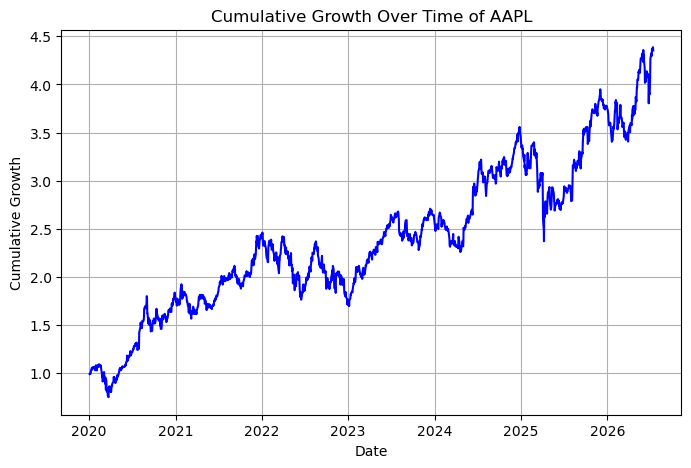

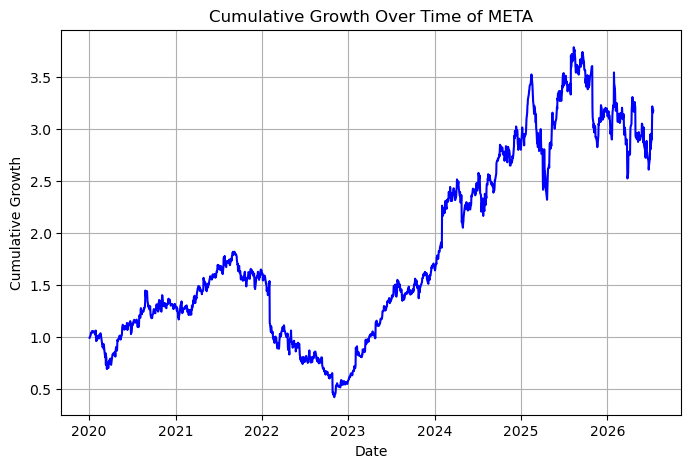

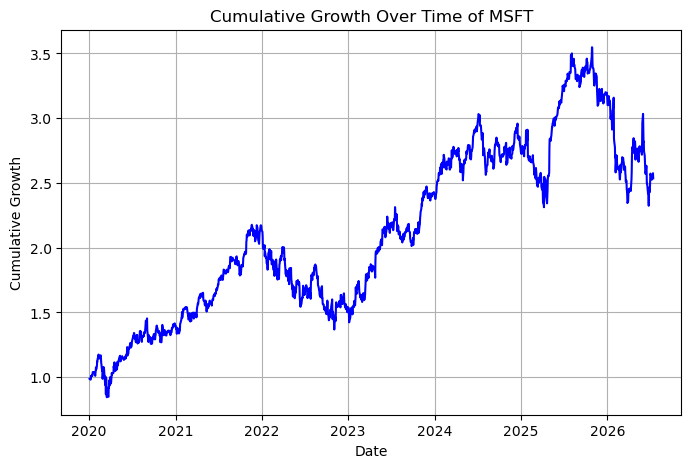

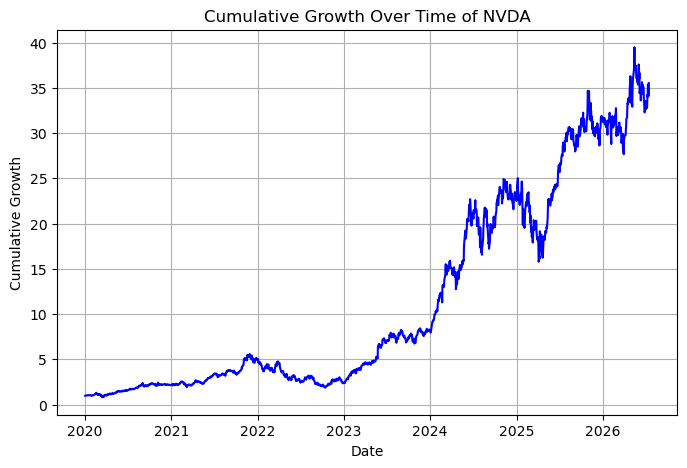

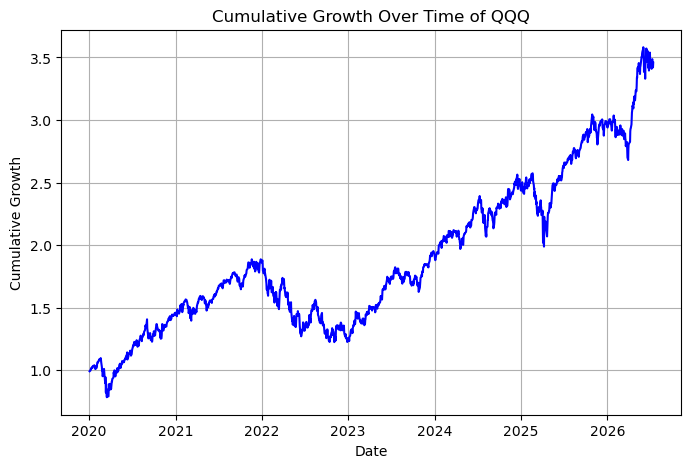

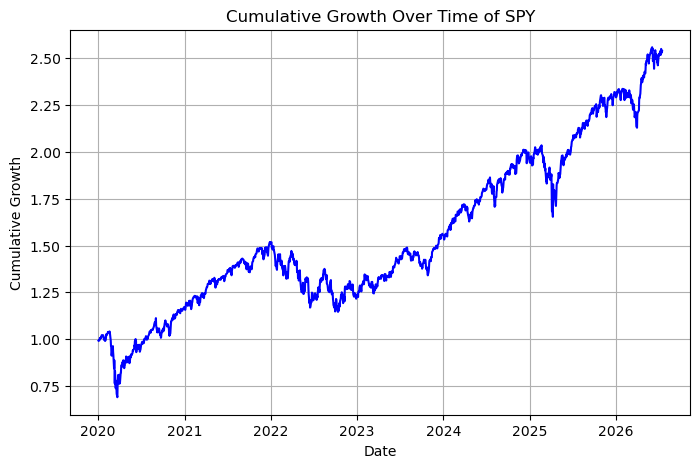

In [61]:
# Individual metrics over time

# Cumulative Growth
for ticker in cumulative_growth:
    plt.figure(figsize = (8, 5))
    plt.plot(cumulative_growth.index, cumulative_growth[ticker], color = "blue")
    plt.title(f"Cumulative Growth Over Time of {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Growth")
    plt.grid(True)
    plt.show()

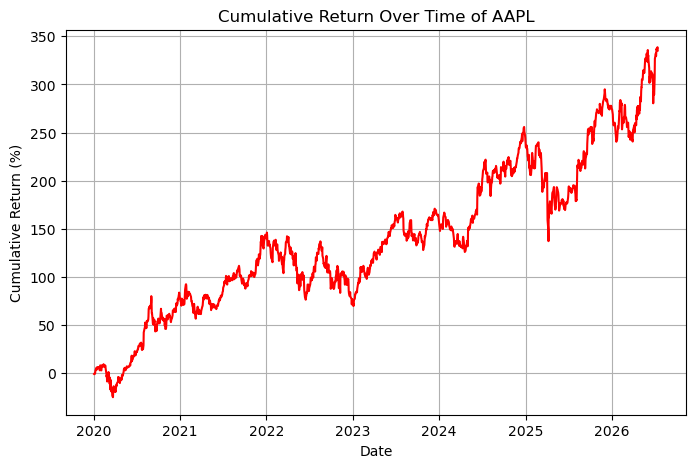

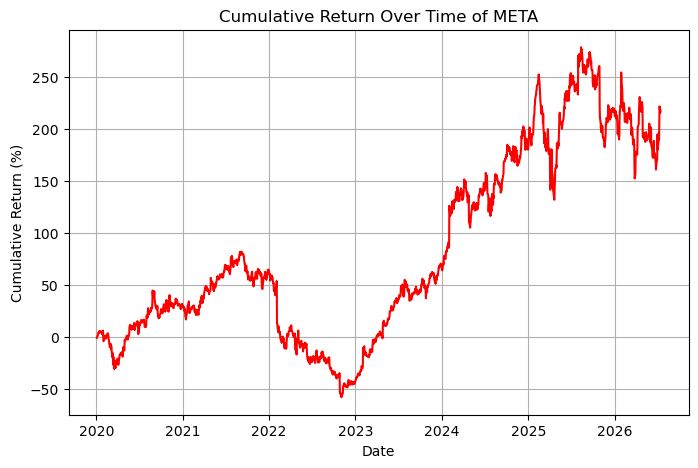

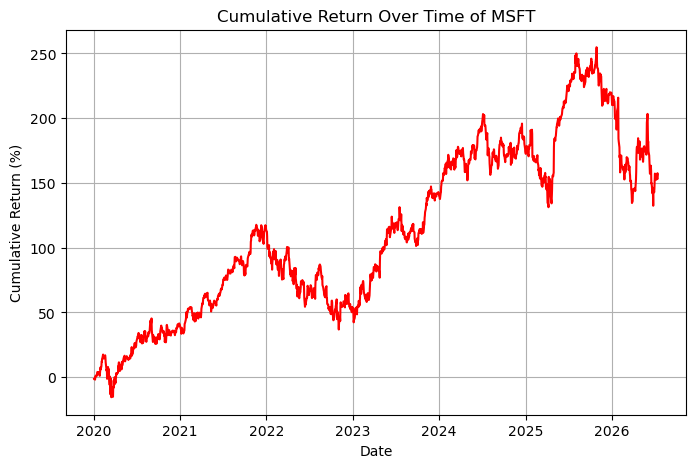

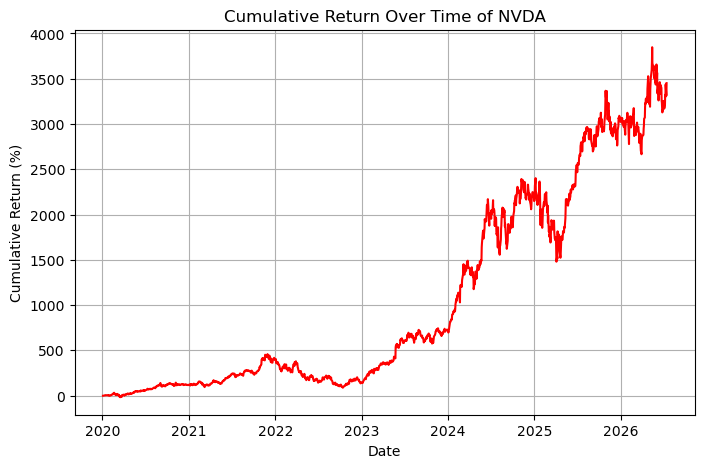

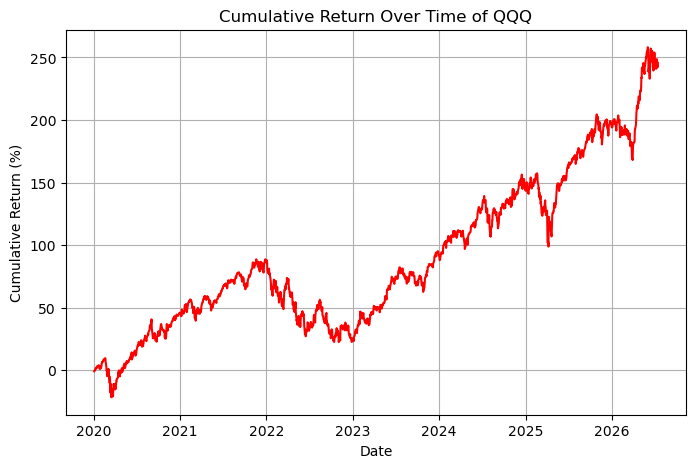

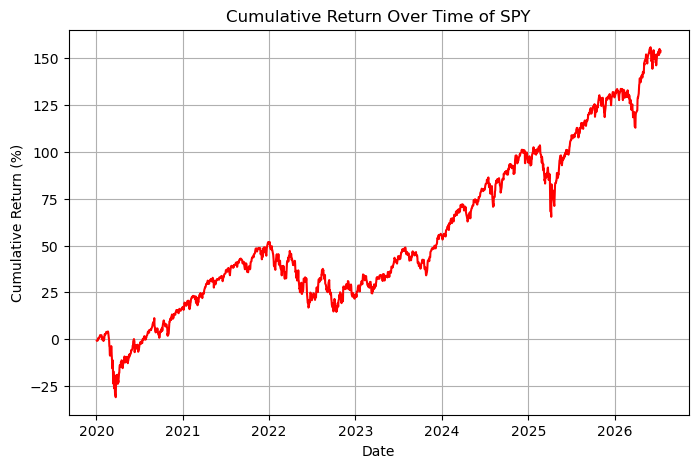

In [64]:
# Cumulative Return
for ticker in cumulative_return:
    plt.figure(figsize = (8, 5))
    plt.plot(cumulative_return.index, cumulative_return[ticker] * 100, color = "red")
    plt.title(f"Cumulative Return Over Time of {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return (%)")
    plt.grid(True)
    plt.show()

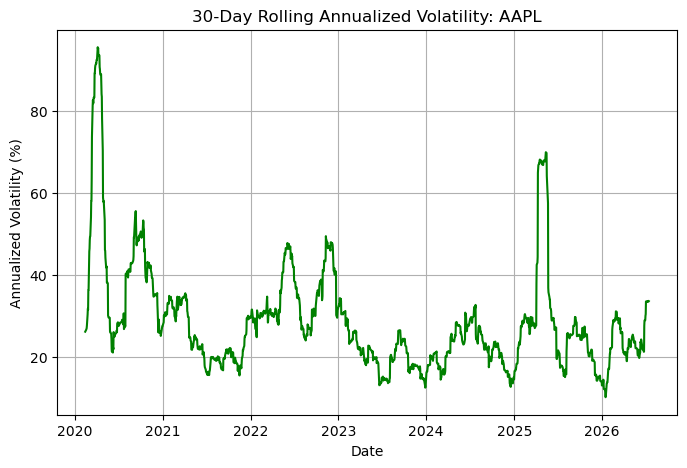

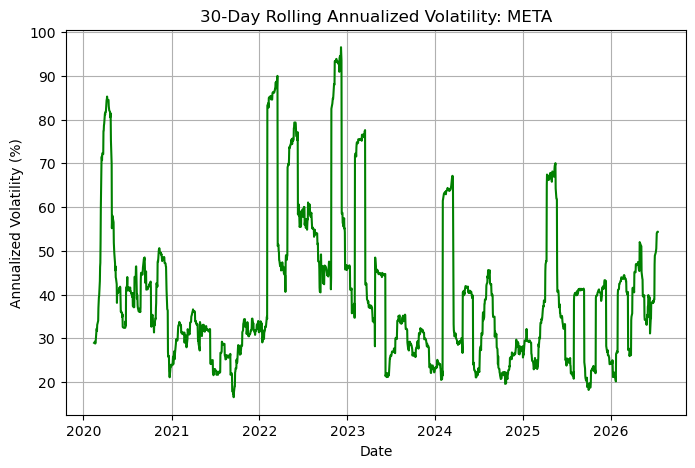

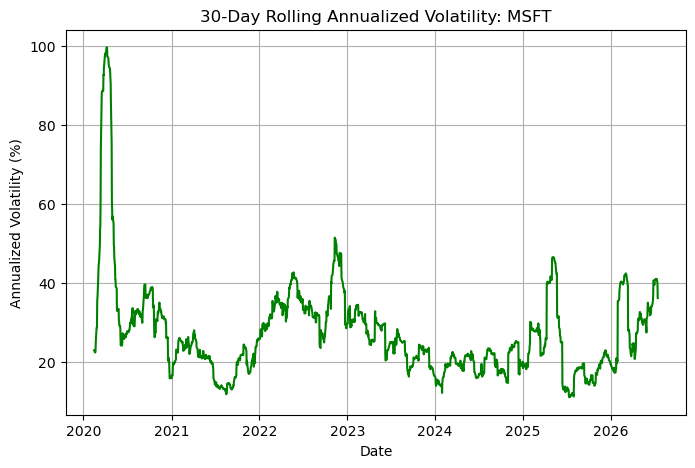

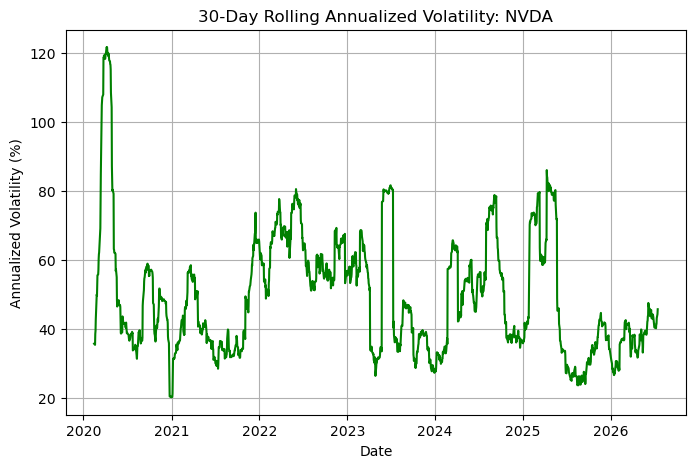

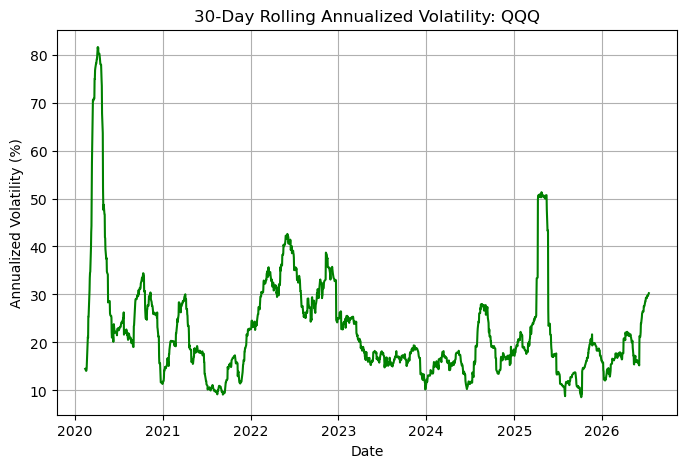

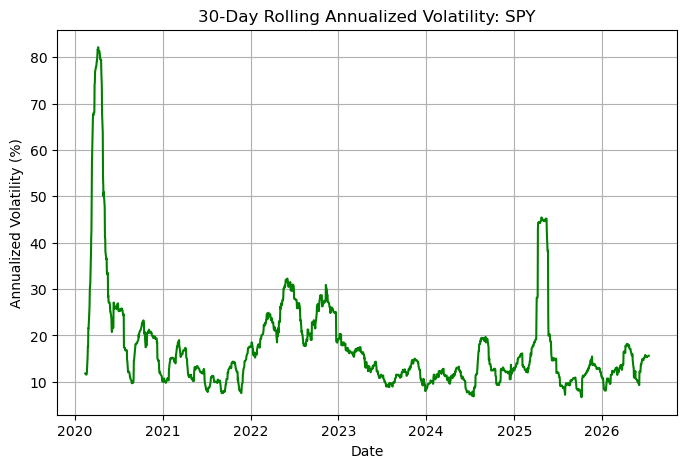

In [76]:
# Rolling Annualiazed Volatility

for ticker in annual_rolling_volatility:
    plt.figure(figsize=(8, 5))

    plt.plot(annual_rolling_volatility.index, annual_rolling_volatility[ticker] * 100, color = "green")

    plt.title(f"30-Day Rolling Annualized Volatility: {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Annualized Volatility (%)")
    plt.grid(True)
    plt.show()

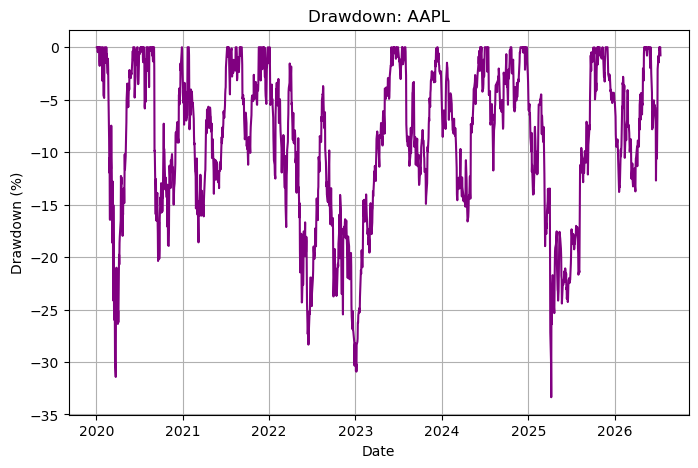

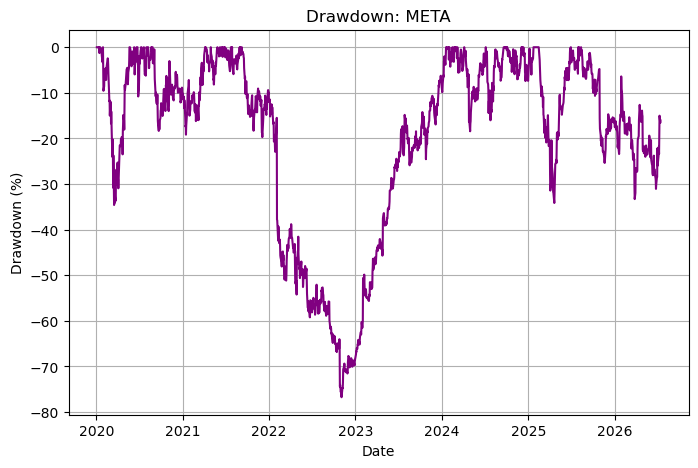

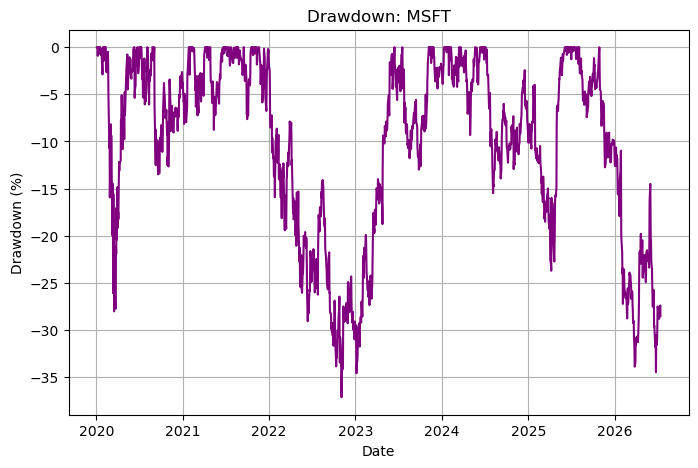

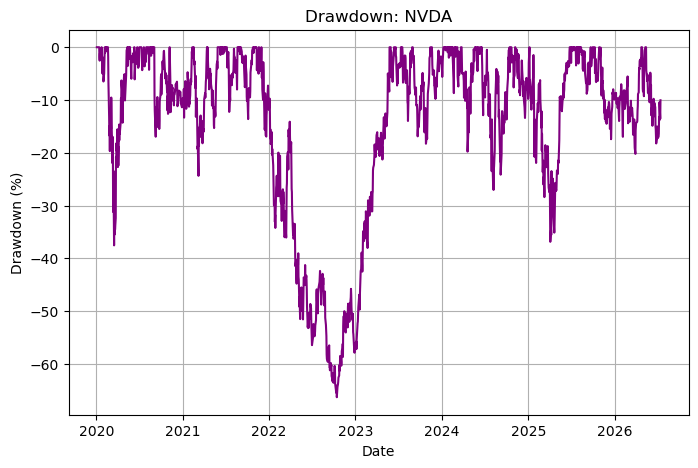

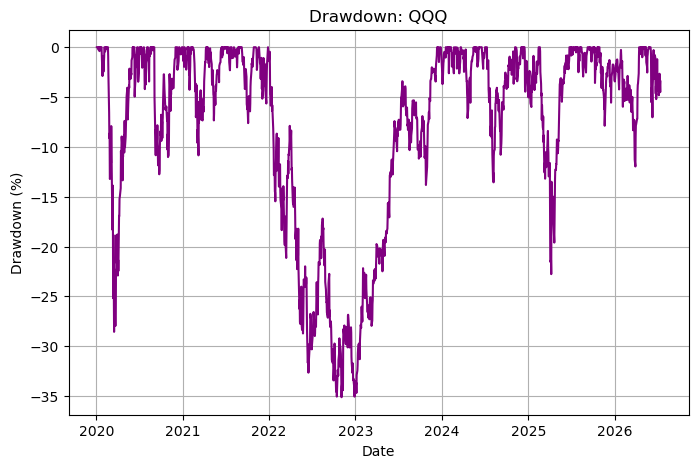

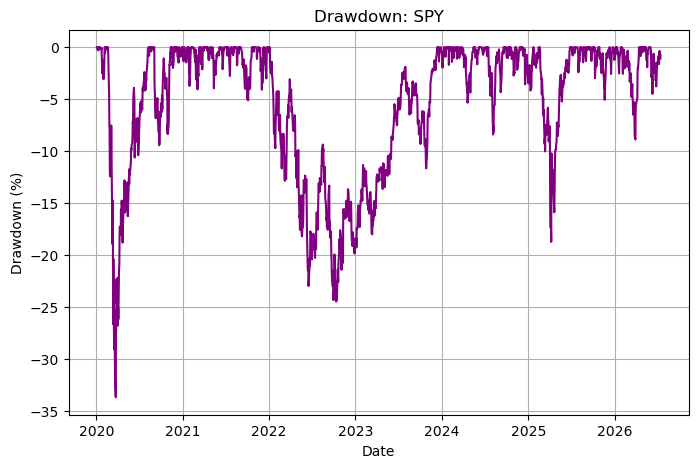

In [75]:
# Drawdown

for ticker in drawdown:
    plt.figure(figsize=(8, 5))

    plt.plot(drawdown.index, drawdown[ticker] * 100, color = "purple")

    plt.title(f"Drawdown: {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Drawdown (%)")
    plt.grid(True)
    plt.show()

### Charts to Compare Metrics

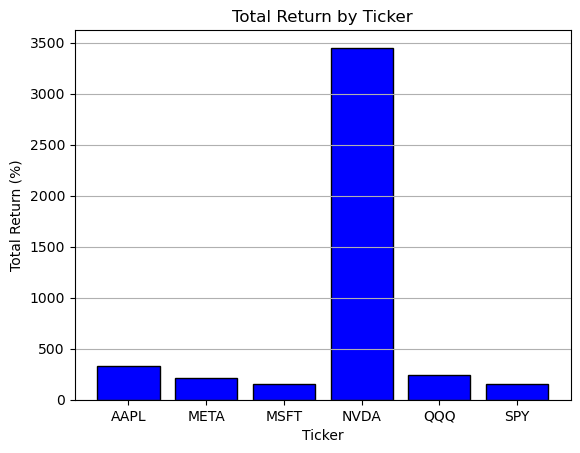

In [93]:
# Total Return Chart

plt.bar(total_return.index, total_return * 100, color = "blue", edgecolor = "black")
plt.xlabel("Ticker")
plt.ylabel("Total Return (%)")
plt.title("Total Return by Ticker")
plt.grid(axis="y")
plt.show()


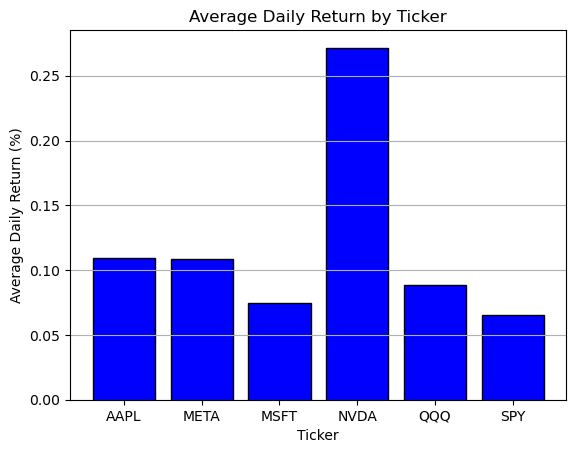

In [94]:
#Average Daily Return

plt.bar(average_dailyreturn.index, average_dailyreturn * 100, color = "blue", edgecolor = "black")
plt.xlabel("Ticker")
plt.ylabel("Average Daily Return (%)")
plt.title("Average Daily Return by Ticker")
plt.grid(axis="y")
plt.show()

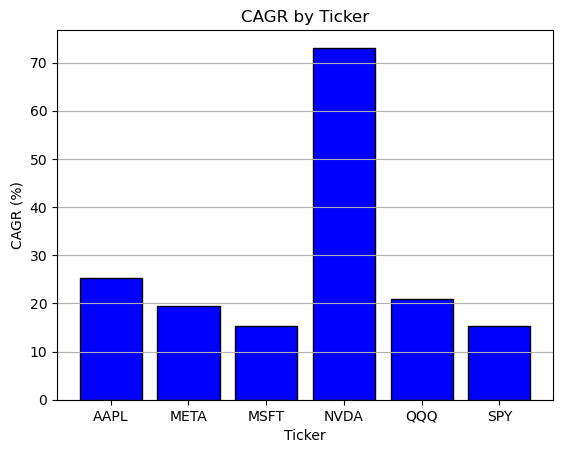

In [95]:
# Annualized Return

plt.bar(cagr.index, cagr * 100, color = "blue", edgecolor = "black")
plt.xlabel("Ticker")
plt.ylabel("CAGR (%)")
plt.title("CAGR by Ticker")
plt.grid(axis="y")
plt.show()

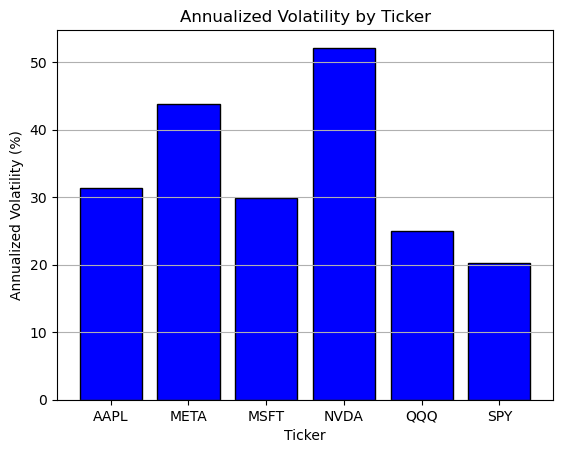

In [96]:
# Volatility

plt.bar(annualized_volatility.index, annualized_volatility * 100, color = "blue", edgecolor = "black")
plt.xlabel("Ticker")
plt.ylabel("Annualized Volatility (%)")
plt.title("Annualized Volatility by Ticker")
plt.grid(axis="y")
plt.show()

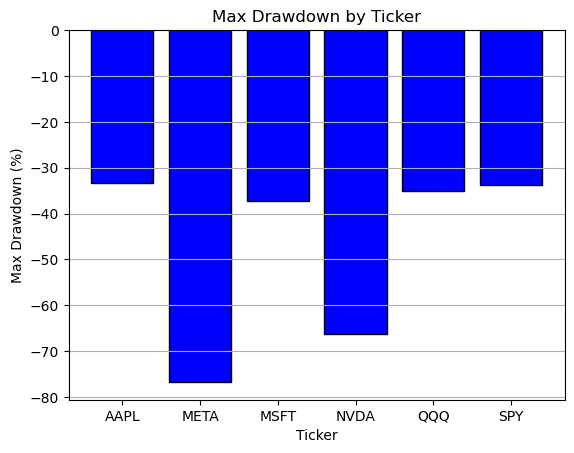

In [101]:
# Max Drawdown

plt.bar(drawdown_max.index, drawdown_max * 100, color = "blue", edgecolor = "black")
plt.xlabel("Ticker")
plt.ylabel("Max Drawdown (%)")
plt.title("Max Drawdown by Ticker")
plt.grid(axis="y")
plt.show()

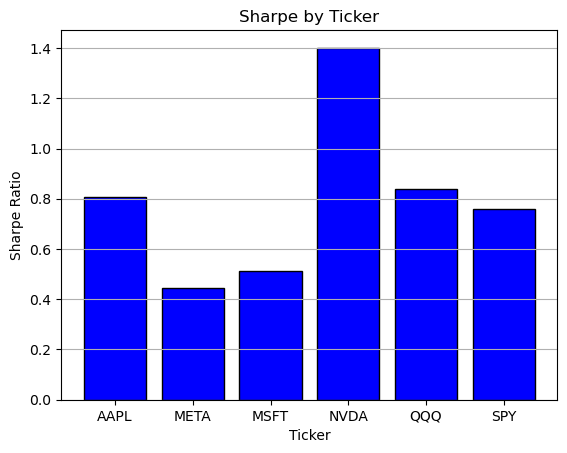

In [104]:
# Sharpe Ratio

plt.bar(sharpe_ratio.index, sharpe_ratio, color = "blue", edgecolor = "black")
plt.xlabel("Ticker")
plt.ylabel("Sharpe Ratio")
plt.title("Sharpe by Ticker")
plt.grid(axis="y")
plt.show()

## Portfolio Visualizations

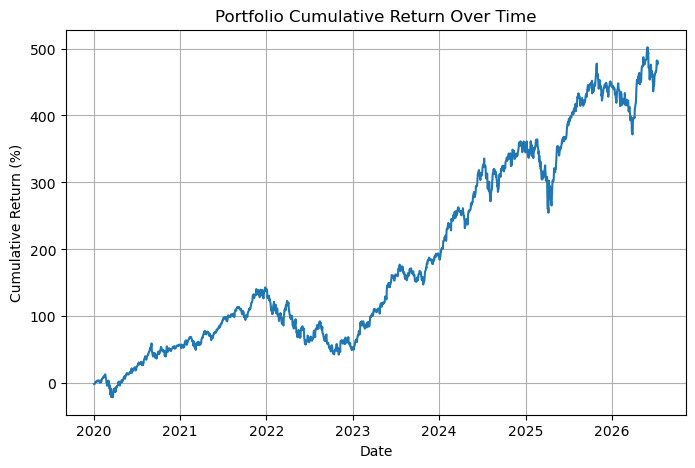

In [105]:
# Portfolio Cumulative Return

plt.figure(figsize=(8, 5))

plt.plot(portfolio_cumulative_return.index, portfolio_cumulative_return * 100)

plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.title("Portfolio Cumulative Return Over Time")
plt.grid(True)
plt.show()

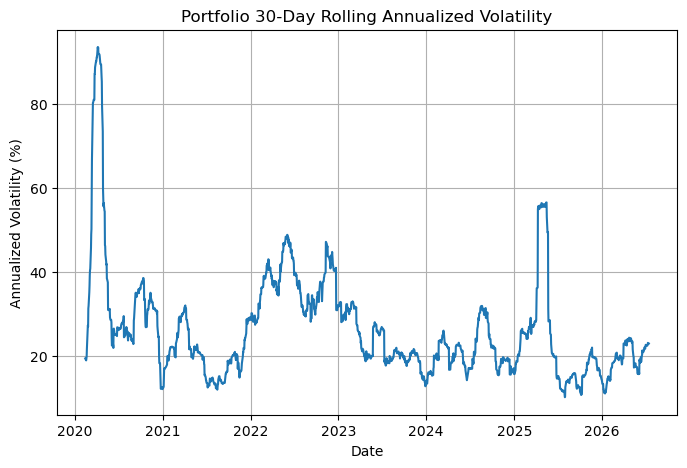

In [106]:
# Portfolio Rolling Volatility

plt.figure(figsize=(8, 5))

plt.plot(portfolio_annual_rolling_volatility.index, portfolio_annual_rolling_volatility * 100)

plt.xlabel("Date")
plt.ylabel("Annualized Volatility (%)")
plt.title("Portfolio 30-Day Rolling Annualized Volatility")
plt.grid(True)
plt.show()

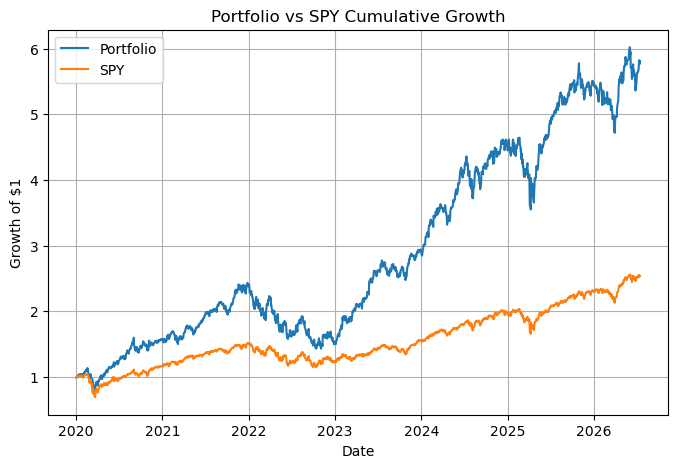

In [108]:
# Portfolio vs SPY Cumulative Growth

spy_cumulative_growth = (1 + daily_returns["SPY"]).cumprod()

portfolio_vs_spy = pd.DataFrame({
    "Portfolio": portfolio_cumulative_growth,
    "SPY": spy_cumulative_growth
})

plt.figure(figsize=(8, 5))

plt.plot(portfolio_vs_spy.index, portfolio_vs_spy["Portfolio"], label="Portfolio")
plt.plot(portfolio_vs_spy.index, portfolio_vs_spy["SPY"], label="SPY")

plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title("Portfolio vs SPY Cumulative Growth")
plt.legend()
plt.grid(True)
plt.show()

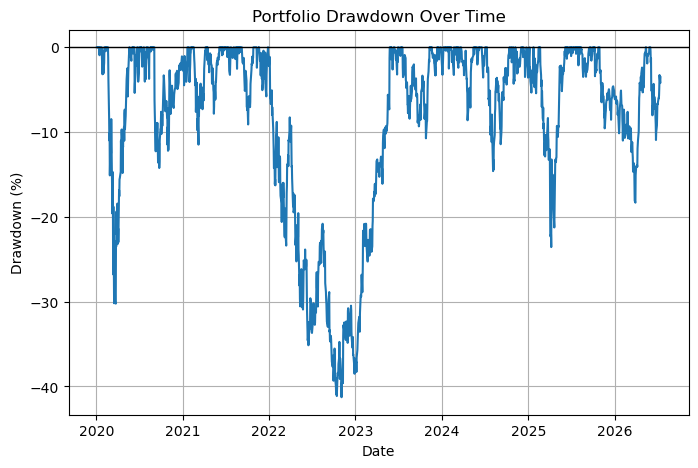

In [109]:
# Portfolio Drawdown Over Time

plt.figure(figsize=(8, 5))

plt.plot(portfolio_drawdown.index, portfolio_drawdown * 100)

plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.title("Portfolio Drawdown Over Time")
plt.grid(True)
plt.show()

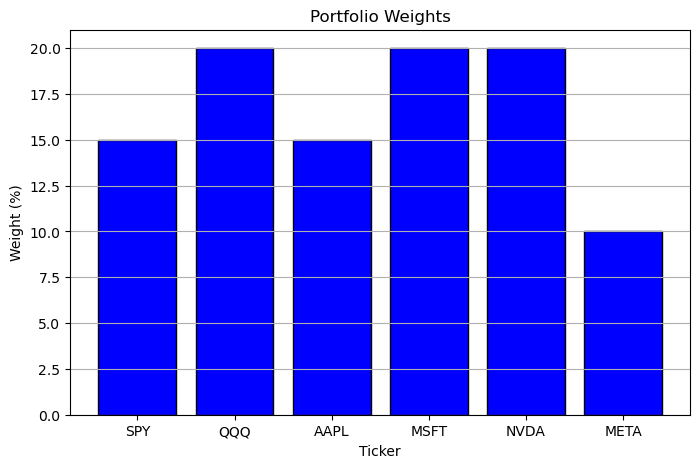

In [111]:
# Portfolio Weights

plt.figure(figsize=(8, 5))

plt.bar(weights.index, weights * 100, color="blue", edgecolor="black")

plt.xlabel("Ticker")
plt.ylabel("Weight (%)")
plt.title("Portfolio Weights")
plt.grid(axis="y")
plt.show()